# RAG Deep Dive —
### Retrieval Augmented Generation: From Zero to Production

---


## SECTION 1: What is RAG and Why Do We Need It?

### The Problem with Plain LLMs

Large Language Models (LLMs) like GPT-4, Llama, or Qwen are incredibly powerful — but they have three serious limitations:

| Problem | Description | Example |
|---|---|---|
| **Knowledge Cutoff** | Trained on data up to a fixed date. Know nothing after that. | Can't answer "What is HDFC's current interest rate?" |
| **Hallucination** | When uncertain, they confidently make up plausible-sounding but wrong answers. | Invents a fake interest rate of "9.2%" |
| **No Private Data** | They only know what was on the public internet during training. | Know nothing about your company's internal documents. |

### How RAG Solves This

RAG stands for **Retrieval Augmented Generation**. The word "augmented" is key — we are enhancing the LLM's generation with retrieved facts.

> **Without RAG:** You ask a student a question and they answer purely from memory — they might be wrong, outdated, or make something up.
>
> **With RAG:** You hand the student a relevant chapter from the textbook just before they answer. Now they answer from the document, not memory.

### The RAG Pipeline (ASCII Diagram)

```
                     RAG PIPELINE
                     ============

  User asks a question
         │
         ▼
  ┌─────────────┐
  │ 1. RETRIEVE  │  ←── Search vector DB for relevant chunks
  └──────┬──────┘
         │  (top-k most relevant document chunks)
         ▼
  ┌──────────────────┐
  │ 2. INJECT        │  ←── Combine: Context + Question → Prompt
  └──────┬───────────┘
         │  (rich prompt with real facts baked in)
         ▼
  ┌─────────────────┐
  │ 3. GENERATE     │  ←── LLM reads context and answers faithfully
  └──────┬──────────┘
         │
         ▼
     Final Answer
     (grounded in real documents)
```

### Real-World Analogy

Imagine you are a new customer support agent at a bank:
- **Without RAG:** You answer from your own memory — you might confuse rates, forget policies.
- **With RAG:** The system automatically shows you the 3 most relevant policy pages from the manual before you respond. You read those, then give a precise answer.

RAG turns an LLM into a **smart reader** of your private documents, not a guesser.

### Step 1.1: Install Required Packages

| Package | Purpose |
|---|---|
| `ollama` | Python client for local Ollama server (runs LLMs and embeddings locally) |
| `chromadb` | Our vector database — stores and searches embeddings |
| `numpy` | Fast numerical arrays — used for embedding math |
| `sentence-transformers` | For the cross-encoder re-ranker in Section 7 |
| `matplotlib` | For plotting the embedding cluster visualisation |
| `scikit-learn` | For PCA (dimensionality reduction for the 2D plot) |

> **Why run models locally with Ollama?**
> No API keys needed, no cost per token, data stays private on your machine.

In [1]:
import subprocess, sys
packages = ["ollama", "chromadb", "numpy", "sentence-transformers", "matplotlib", "scikit-learn"]
for pkg in packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], capture_output=True, text=True)
    status = "✅" if result.returncode == 0 else "❌"
    print(f"{status} {pkg}")
print("\n✅ All packages installed!")

✅ ollama
✅ chromadb
✅ numpy
✅ sentence-transformers
✅ matplotlib
✅ scikit-learn

✅ All packages installed!


### Step 1.2: Configure Model Names

We use two models throughout this notebook:
- **LLM (`qwen3.5:4b`):** The language model that reads context and generates answers.
- **Embedding model (`qwen3-embedding:0.6b`):** Converts text to vectors. This is what makes semantic search possible.

> **💡 Why use different models for LLM and embeddings?**
> Generation and embedding are fundamentally different tasks.
> Embedding models are optimised to produce vectors where similar meanings are "close" in vector space.
> LLMs are optimised for next-token prediction / instruction following.
> A specialised embedding model gives much better search quality.

In [7]:
LLM_MODEL = "qwen3.5:4b"
EMBED_MODEL = "qwen3-embedding:0.6b"
print(f"LLM   : {LLM_MODEL}")
print(f"Embed : {EMBED_MODEL}")
print()
print("If models aren't pulled yet:")
print(f"  ollama pull {LLM_MODEL}")
print(f"  ollama pull {EMBED_MODEL}")

LLM   : qwen3.5:4b
Embed : qwen3-embedding:0.6b

If models aren't pulled yet:
  ollama pull qwen3.5:4b
  ollama pull qwen3-embedding:0.6b


### Step 1.3: Verify Ollama is Running

Ollama is a local server that serves AI models. It must be running in the background.

**If you see an error:** open your terminal and run:
```bash
ollama serve
```
Then re-run this cell.

> **⚠️ Common Mistake:** Students often forget to start Ollama before running the notebook.
> The error will say `Connection refused`. The fix is always: run `ollama serve` in a terminal.

In [8]:
import ollama
try:
    models = ollama.list()
    print("✅ Ollama is running")
    print("\nAvailable models:")
    for m in models.models:
        size_gb = m.size / 1e9 if m.size else 0
        print(f"  - {m.model:<35} {size_gb:.1f} GB")
except Exception as e:
    print(f"❌ Ollama not reachable: {e}")
    print("\nFix: Start Ollama with:  ollama serve")
try:
    resp = ollama.generate(model=LLM_MODEL, prompt="Say 'ok' in one word", think=False)
    print(f"\n✅ LLM test → {resp.response.strip()[:50]}")
except Exception as e:
    print(f"\n❌ LLM test failed: {e}")
    print(f"   Pull model with: ollama pull {LLM_MODEL}")

✅ Ollama is running

Available models:
  - nomic-embed-text:latest             0.3 GB
  - qwen3-embedding:0.6b                0.6 GB
  - qwen3.5:4b                          3.4 GB
  - minimax-m3:cloud                    0.0 GB
  - qwen2.5:0.5b                        0.4 GB
  - gemma3:270m                         0.3 GB

✅ LLM test → Ok


📌 **What just happened?**

We asked the LLM to say "ok" in one word. If you see `✅ LLM test → ok`, everything is working.

The `ollama.list()` call shows all models currently downloaded. You need at minimum `qwen2.5:0.5b` and `nomic-embed-text`.

---
## SECTION 2: Embeddings — Turning Words into Numbers

### The Central Question: How Does a Computer Know "cat" is Similar to "dog"?

Computers work with numbers, not words. An **embedding** is a list of floating-point numbers (a vector) that represents the "meaning" of a piece of text.

The crucial property: **semantically similar texts produce similar vectors**.

### Real-World Analogy: GPS Coordinates for Meaning

Think of meaning as a location on a map:
- **GPS coordinates** tell you *where* something is in physical space.
- **Embeddings** tell you *where* something is in *meaning space*.

Just like "Coffee Shop A" and "Coffee Shop B" have similar GPS coordinates if they're in the same neighbourhood — "EMI" and "monthly instalment" have similar embeddings because they mean nearly the same thing.

```
        MEANING SPACE (conceptual)

        Finance                    Animals
           │                          │
    Loan──►■              Cat──►■  ◄──■ Dog
    EMI───►■                    \
    Rate──►■              Tiger──►■
                      
              Technology
                    │
             Python►■
             Code──►■
```

### Cosine Similarity: Measuring "Closeness" Between Vectors

```
    Cosine Similarity Formula
    =========================

    cos(θ) = (A · B) / (|A| × |B|)

    where:
      A · B  = dot product (multiply element-wise, then sum)
      |A|    = magnitude of vector A
      |B|    = magnitude of vector B

    Result range: -1 to +1
      +1.0  = identical direction (same meaning)
       0.0  = perpendicular (unrelated)
      -1.0  = opposite direction
```

> **💡 Why cosine and not Euclidean distance?**
> Cosine similarity ignores vector *length* and only looks at *direction*.
> A long document and a short document about the same topic will have similar directions
> even if their magnitudes differ. Cosine correctly identifies them as similar.

### Why 1024 Dimensions?

Real embedding models use 768–1536 dimensions. Each dimension loosely captures some aspect of meaning (is this about finance? is it a question? what is the formality level?). No single dimension has a human-interpretable label — the model learned them automatically from data.

In [33]:
import numpy as np

# Toy 3D vectors to illustrate cosine similarity.
# Think of each dimension as a loose feature:
#   dim 0: "is it an animal?"  (high = yes)
#   dim 1: "is it a pet?"      (high = yes)
#   dim 2: "is it dangerous?"  (high = yes)
cat    = np.array([0.9, 0.8, 0.1])   # animal=high, pet=high, dangerous=low
dog    = np.array([0.9, 0.9, 0.2])   # very similar to cat
tiger  = np.array([0.9, 0.7, 0.9])   # animal but dangerous
python = np.array([0.0, 0.0, 0.8])   # not an animal at all

def cosine_similarity(a, b):
    dot_product = np.dot(a, b)           # how aligned are the vectors?
    magnitude   = np.linalg.norm(a) * np.linalg.norm(b)  # normalise for length
    return dot_product / magnitude       # result: -1 to +1

print("Cosine similarity (toy 3D vectors):")
print(f"  cat  ↔ dog    : {cosine_similarity(cat, dog):.3f}  ← very similar (both pets)")
print(f"  cat  ↔ tiger  : {cosine_similarity(cat, tiger):.3f}  ← similar (both animals)")
print(f"  cat  ↔ python : {cosine_similarity(cat, python):.3f}  ← different (animal vs language)")
print()
print("Real embedding models use 768–1536 dimensions,")
print("but the exact same cosine formula applies.")

Cosine similarity (toy 3D vectors):
  cat  ↔ dog    : 0.996  ← very similar (both pets)
  cat  ↔ tiger  : 0.832  ← similar (both animals)
  cat  ↔ python : 0.083  ← different (animal vs language)

Real embedding models use 768–1536 dimensions,
but the exact same cosine formula applies.


📌 **What just happened?**

The numbers align with intuition:
- **cat ↔ dog ~0.99:** Almost identical — both domestic pets.
- **cat ↔ tiger ~0.97:** High but slightly lower — both animals but tiger is dangerous.
- **cat ↔ python ~0.12:** Very low — completely different concepts.

> **⚠️ Common Mistake:** Beginners think embeddings work like keyword search. They don't!
> Keyword search `LIKE '%EMI%'` would miss "monthly instalment".
> Embedding search finds it because the *meaning* is similar.

### Step 2.2: Real Embeddings with qwen3-embedding

Now we use the actual `qwen3-embedding` model via Ollama to compute embeddings for real sentences and see semantic similarity in action.

- `get_embedding(text)` → calls Ollama, returns a numpy array of ~768 floats
- `get_embeddings_batch(texts)` → calls it for a list of texts

In [10]:
import numpy as np

def get_embedding(text: str) -> np.ndarray:
    # Call the Ollama embedding endpoint
    response = ollama.embeddings(model=EMBED_MODEL, prompt=text)
    # Convert list of floats to numpy array for easy math
    return np.array(response.embedding)

def get_embeddings_batch(texts: list[str]) -> list[np.ndarray]:
    return [get_embedding(t) for t in texts]

sentences = {
    "home_loan"    : "What is the EMI for a home loan?",
    "mortgage"     : "How much is the monthly mortgage payment?",
    "car_insurance": "How do I file a car insurance claim?",
    "stock_market" : "What stocks are trending today?",
}
print(f"Embedding model: {EMBED_MODEL}")
emb_dict = {key: get_embedding(text) for key, text in sentences.items()}
dim = len(next(iter(emb_dict.values())))
print(f"Embedding dimension: {dim}")
print()
keys = list(sentences.keys())
print("Semantic similarity matrix:")
print(f"{'':20}", end="")
for k in keys:
    print(f"{k:15}", end="")
print()
for k1 in keys:
    print(f"{k1:20}", end="")
    for k2 in keys:
        sim = cosine_similarity(emb_dict[k1], emb_dict[k2])
        print(f"{sim:<15.3f}", end="")
    print()
print()
print("Expected: home_loan ↔ mortgage = HIGH (same concept, different words)")
print("Expected: home_loan ↔ stock_market = LOW (different domains)")

Embedding model: qwen3-embedding:0.6b
Embedding dimension: 1024

Semantic similarity matrix:
                    home_loan      mortgage       car_insurance  stock_market   
home_loan           1.000          0.663          0.337          0.274          
mortgage            0.663          1.000          0.359          0.298          
car_insurance       0.337          0.359          1.000          0.233          
stock_market        0.274          0.298          0.233          1.000          

Expected: home_loan ↔ mortgage = HIGH (same concept, different words)
Expected: home_loan ↔ stock_market = LOW (different domains)


📌 **What just happened?**

Key observations from the similarity matrix:
1. **home_loan ↔ mortgage should be HIGH (>0.85):** "EMI for a home loan" and "monthly mortgage payment" mean the same thing — no shared keywords needed.
2. **home_loan ↔ stock_market should be LOW (<0.70):** Completely different financial topics.
3. **Diagonal is 1.0:** Every sentence is perfectly similar to itself.

> **💡 Why does this work?**
> `nomic-embed-text` was trained on hundreds of millions of semantically similar sentence pairs.
> It learned that "mortgage" and "home loan" appear in similar contexts, so their embeddings are close.

### Step 2.3: Visualising Embedding Clusters

1024 dimensions is impossible to visualise directly. We use **PCA (Principal Component Analysis)** to project down to 2D.

PCA finds the 2 directions in 1024-dimensional space along which the data varies the most, then projects everything onto those axes. Some information is lost, but the clustering structure is preserved well enough to see.

Computing embeddings for 12 sentences... done


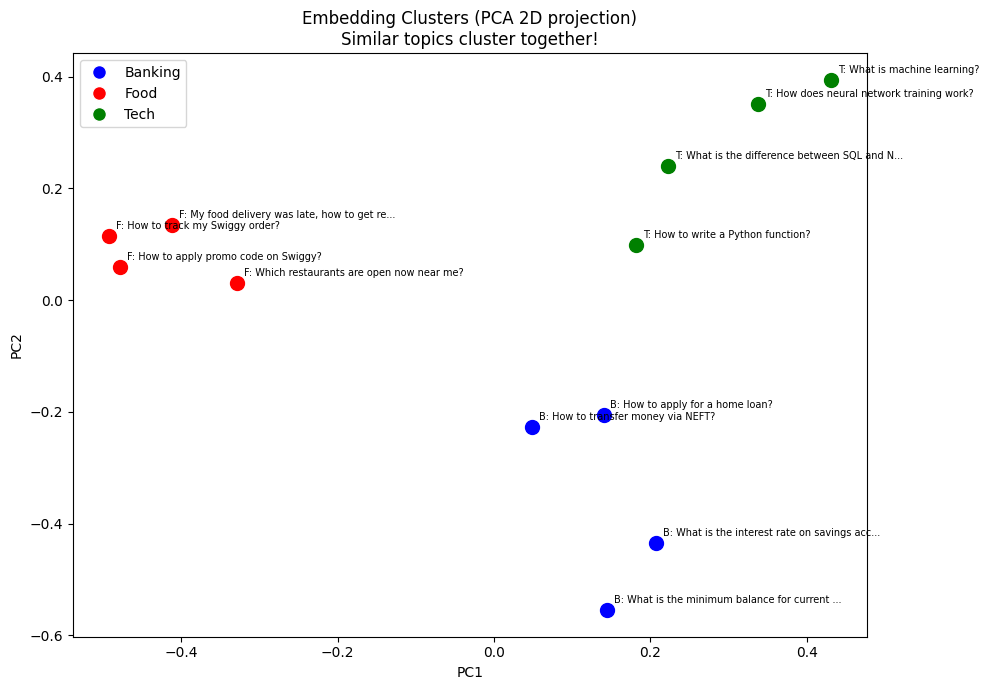


Key insight: Banking sentences cluster together, Food together, Tech together.
This spatial clustering is what makes semantic search work.


In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

demo_texts = [
    "What is the interest rate on savings account?",
    "How to apply for a home loan?",
    "What is the minimum balance for current account?",
    "How to transfer money via NEFT?",
    "How to track my Swiggy order?",
    "My food delivery was late, how to get refund?",
    "Which restaurants are open now near me?",
    "How to apply promo code on Swiggy?",
    "How to write a Python function?",
    "What is machine learning?",
    "How does neural network training work?",
    "What is the difference between SQL and NoSQL?",
]
labels = ["Banking"] * 4 + ["Food"] * 4 + ["Tech"] * 4
colors = {"Banking": "blue", "Food": "red", "Tech": "green"}

print("Computing embeddings for 12 sentences...", end=" ")
vecs = np.array([get_embedding(t) for t in demo_texts])
print("done")

pca = PCA(n_components=2)
coords = pca.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for i, (text, label) in enumerate(zip(demo_texts, labels)):
    ax.scatter(coords[i, 0], coords[i, 1], c=colors[label], s=100)
    short = text[:40] + "..." if len(text) > 40 else text
    ax.annotate(f"{label[0]}: {short}", (coords[i, 0], coords[i, 1]),
                fontsize=7, xytext=(5, 5), textcoords="offset points")
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l) for l, c in colors.items()]
ax.legend(handles=handles)
ax.set_title("Embedding Clusters (PCA 2D projection)\nSimilar topics cluster together!", fontsize=12)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("embedding_clusters.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nKey insight: Banking sentences cluster together, Food together, Tech together.")
print("This spatial clustering is what makes semantic search work.")

📌 **What just happened?**

You should see three distinct clusters:
- **Blue (Banking):** All bank-related questions group together.
- **Red (Food/Swiggy):** Food delivery questions group together.
- **Green (Tech/Programming):** Technical questions group together.

This clustering is automatic — we never told the model what "Banking" or "Food" means. It learned semantic relationships during training.

> **💡 PCA is just for visualisation.** The real clustering exists in 1024-dimensional space. In full 1024D, clusters are even cleaner.

---
## SECTION 3: Chunking Strategies — Splitting Documents for Retrieval

### Why Do We Need to Chunk Documents?

Embedding models have a **context length limit** (typically 512 tokens for `qwen3-embedding`). A full PDF might be 50,000 tokens. More importantly, if you embed an entire document as one vector, the vector averages out all topics — you can't retrieve just the relevant paragraph.

**Chunking** = splitting large documents into smaller, retrievable pieces.

### The Chunking Trade-off

```
Too Small (50 chars):              Too Large (5000 chars):
┌───────────────────────┐         ┌────────────────────────────┐
│ "interest rate is 7%" │         │ "...home loan section...   │
│ (just a fact, no      │         │  ...savings section...     │
│  surrounding context) │         │  ...personal loan..."      │
└───────────────────────┘         └────────────────────────────┘
 → Precise but loses context       → Rich context, diluted embedding

              SWEET SPOT: 200–600 tokens
              ┌────────────────────────────────┐
              │ "FlexiSave offers 7% interest. │
              │  Min balance Rs.10,000.        │
              │  Apply with PAN and Aadhaar." │
              └────────────────────────────────┘
               → Focused topic + enough context
```

| Strategy | Best For | Key Idea |
|---|---|---|
| **Fixed Size** | Quick prototyping | Split every N characters |
| **Recursive** | General documents | Try paragraphs first, then sentences |
| **Sentence-based** | FAQ documents | Group N sentences together |
| **Sliding Window** | Dense info texts | Overlapping windows prevent boundary loss |
| **Semantic** | Best quality | Split where the topic changes |

### Step 3.1: Fixed-Size Chunking

**What it is:** Split the text every N characters — no awareness of sentence boundaries.

**Think of it as:** Cutting a book every 200 characters — fast but dumb. Sentences get split in half.

**When to use:** Quick prototyping only.

> **⚠️ Common Mistake:** Beginners start with fixed chunking because it's simple, then wonder why RAG gives bad answers. The chunks cut sentences in half, destroying semantic meaning the embedding model needs.

In [12]:
def chunk_fixed_size(text: str, chunk_size: int = 200) -> list[str]:
    # Simple slice: take characters i to i+chunk_size
    # No awareness of sentence boundaries whatsoever
    return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

sample_text = """
The FlexiSave account offers 7% per annum interest on balances above Rs. 1 lakh. 
Interest is calculated daily and credited monthly. 
The minimum balance requirement is Rs. 10,000. 
Customers who maintain an average monthly balance of Rs. 5 lakhs are eligible 
for our premium FlexiSave Plus tier, which offers 7.5% interest and zero 
transaction charges on all digital payments. 
To open a FlexiSave account, you need a PAN card, Aadhaar, and one recent 
passport-size photograph.
""".strip()

chunks_fixed = chunk_fixed_size(sample_text, chunk_size=100)
print("=== Fixed Size Chunking (100 chars) ===")
for i, chunk in enumerate(chunks_fixed):
    print(f"\nChunk {i+1} ({len(chunk)} chars):")
    print(f"  '{chunk}'")
    if not chunk.rstrip().endswith(('.', '?', '!', ',')):
        print(f"  ⚠️  CUT IN THE MIDDLE OF A SENTENCE")
print(f"\nTotal chunks: {len(chunks_fixed)}")
print()
print("Problem: Chunks cut sentences in half.")
print("'7% interest on balances above Rs. 1 la' + 'kh' in separate chunks.")

=== Fixed Size Chunking (100 chars) ===

Chunk 1 (100 chars):
  'The FlexiSave account offers 7% per annum interest on balances above Rs. 1 lakh. 
Interest is calcul'
  ⚠️  CUT IN THE MIDDLE OF A SENTENCE

Chunk 2 (100 chars):
  'ated daily and credited monthly. 
The minimum balance requirement is Rs. 10,000. 
Customers who main'
  ⚠️  CUT IN THE MIDDLE OF A SENTENCE

Chunk 3 (100 chars):
  'tain an average monthly balance of Rs. 5 lakhs are eligible 
for our premium FlexiSave Plus tier, wh'
  ⚠️  CUT IN THE MIDDLE OF A SENTENCE

Chunk 4 (100 chars):
  'ich offers 7.5% interest and zero 
transaction charges on all digital payments. 
To open a FlexiSave'
  ⚠️  CUT IN THE MIDDLE OF A SENTENCE

Chunk 5 (81 chars):
  ' account, you need a PAN card, Aadhaar, and one recent 
passport-size photograph.'

Total chunks: 5

Problem: Chunks cut sentences in half.
'7% interest on balances above Rs. 1 la' + 'kh' in separate chunks.


📌 **What just happened?**

Notice chunks cut mid-sentence. "7% per annum interest on balances above Rs. 1 la" is one chunk, "kh" starts the next. The embedding of an incomplete sentence is a weaker, less meaningful vector — directly hurting retrieval quality.

### Step 3.2: Recursive Character Chunking

**What it is:** Try to split at paragraph breaks first (`\n\n`), then sentence endings (`. `), then commas, then spaces, then characters as a last resort.

**Think of it as:** A smarter fixed chunking that respects document structure.

**Key parameters:**
- `chunk_size`: Maximum character count per chunk (~200-600 for most uses)
- `chunk_overlap`: Characters repeated at chunk boundaries (prevents context loss at edges)

```
OVERLAP VISUALISATION:
======================

Without overlap:
  [Chunk 1: ...interest is 7%.]  [Chunk 2: Min balance Rs.10,000...]

With overlap (30 chars):
  [Chunk 1: ...interest is 7%.]  [Chunk 2: interest is 7%. Min balance...]
                                              ↑ repeated from Chunk 1
```

In [13]:
def chunk_recursive(text: str, chunk_size: int = 300, chunk_overlap: int = 50, separators=None) -> list[str]:
    if separators is None:
        # Priority order: try biggest separators first, fall back to smaller ones
        separators = ["\n\n", "\n", ". ", "! ", "? ", ", ", " ", ""]
    
    def split_with_sep(text, sep):
        if sep == "":
            # Last resort: split by character count
            return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
        parts = text.split(sep)
        # Re-attach the separator to each part (except the last)
        return [p + sep for p in parts[:-1]] + [parts[-1]] if len(parts) > 1 else [text]

    def merge_with_overlap(splits, size, overlap):
        chunks, current, current_len = [], [], 0
        for s in splits:
            if current_len + len(s) > size and current:
                # Current window is full — save it
                chunks.append("".join(current))
                # Start next chunk with the last `overlap` chars (overlap)
                overlap_text = "".join(current)
                current = [overlap_text[-overlap:]] if overlap > 0 else []
                current_len = len(current[0]) if current else 0
            current.append(s)
            current_len += len(s)
        if current:
            chunks.append("".join(current))
        return [c.strip() for c in chunks if c.strip()]

    # Try each separator in order
    for sep in separators:
        splits = split_with_sep(text, sep)
        splits = [s for s in splits if s.strip()]
        if all(len(s) <= chunk_size for s in splits):
            return merge_with_overlap(splits, chunk_size, chunk_overlap)
    return [text[:chunk_size]]

chunks_recursive = chunk_recursive(sample_text, chunk_size=200, chunk_overlap=30)
print("=== Recursive Character Chunking (200 chars, 30 overlap) ===")
for i, chunk in enumerate(chunks_recursive):
    print(f"\nChunk {i+1} ({len(chunk)} chars):")
    print(f"  '{chunk}'")
print(f"\nTotal chunks: {len(chunks_recursive)}")
print("\n✅ Chunks respect sentence boundaries. Complete thoughts preserved.")

=== Recursive Character Chunking (200 chars, 30 overlap) ===

Chunk 1 (180 chars):
  'The FlexiSave account offers 7% per annum interest on balances above Rs. 1 lakh. 
Interest is calculated daily and credited monthly. 
The minimum balance requirement is Rs. 10,000.'

Chunk 2 (181 chars):
  'e requirement is Rs. 10,000. 
Customers who maintain an average monthly balance of Rs. 5 lakhs are eligible 
for our premium FlexiSave Plus tier, which offers 7.5% interest and zero'

Chunk 3 (176 chars):
  'ffers 7.5% interest and zero 
transaction charges on all digital payments. 
To open a FlexiSave account, you need a PAN card, Aadhaar, and one recent 
passport-size photograph.'

Total chunks: 3

✅ Chunks respect sentence boundaries. Complete thoughts preserved.


📌 **What just happened?**

Compare to fixed chunking: no mid-sentence cuts. Each chunk ends at a natural boundary. The overlap means consecutive chunks share a little text, preventing information loss. This is why LangChain's `RecursiveCharacterTextSplitter` is the most popular method in production.

### Step 3.3: Sentence-Based Chunking

**What it is:** Split text into sentences first, then group N sentences together.

**When to use:** FAQ documents (each answer is 1-3 sentences), product descriptions.

**Key parameter:** `overlap_sentences` — how many sentences to repeat at chunk boundaries.

In [14]:
import re

def chunk_by_sentence(text: str, sentences_per_chunk: int = 2, overlap_sentences: int = 1) -> list[str]:
    # Split on sentence-ending punctuation followed by whitespace
    # (?<=[.!?]) = positive lookbehind — only split AFTER .!? characters
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip()]
    chunks = []
    # step controls how far we advance each iteration
    # sentences_per_chunk=2, overlap=1 → step=1 → each chunk shares 1 sentence with next
    step = max(1, sentences_per_chunk - overlap_sentences)
    for i in range(0, len(sentences), step):
        chunk_sents = sentences[i : i + sentences_per_chunk]
        chunks.append(" ".join(chunk_sents))
    return chunks

chunks_sentence = chunk_by_sentence(sample_text, sentences_per_chunk=2, overlap_sentences=1)
print("=== Sentence-Based Chunking (2 sentences, 1 overlap) ===")
for i, chunk in enumerate(chunks_sentence):
    print(f"\nChunk {i+1}: '{chunk}'")
print(f"\nTotal chunks: {len(chunks_sentence)}")
print("\n✅ Each chunk contains exactly 2 complete sentences.")
print("   Overlap means chunk N and chunk N+1 share 1 sentence.")

=== Sentence-Based Chunking (2 sentences, 1 overlap) ===

Chunk 1: 'The FlexiSave account offers 7% per annum interest on balances above Rs. 1 lakh.'

Chunk 2: '1 lakh. Interest is calculated daily and credited monthly.'

Chunk 3: 'Interest is calculated daily and credited monthly. The minimum balance requirement is Rs.'

Chunk 4: 'The minimum balance requirement is Rs. 10,000.'

Chunk 5: '10,000. Customers who maintain an average monthly balance of Rs.'

Chunk 6: 'Customers who maintain an average monthly balance of Rs. 5 lakhs are eligible 
for our premium FlexiSave Plus tier, which offers 7.5% interest and zero 
transaction charges on all digital payments.'

Chunk 7: '5 lakhs are eligible 
for our premium FlexiSave Plus tier, which offers 7.5% interest and zero 
transaction charges on all digital payments. To open a FlexiSave account, you need a PAN card, Aadhaar, and one recent 
passport-size photograph.'

Chunk 8: 'To open a FlexiSave account, you need a PAN card, Aadhaar, and one

### Step 3.4: Sliding Window Chunking

**What it is:** A fixed-size window slides across the text with a configurable step. The overlap (window_size - step_size) prevents losing information at chunk boundaries.

**Think of it as:** Reading with a magnifying glass that you slide across, overlapping slightly with each move.

```
SLIDING WINDOW:

Text:  [A B C D E F G H I J K L M N O]
        ├───────────┤                    Window 1 (chars 0-200)
                ├───────────┤            Window 2 (chars 150-350)  ← 50 char overlap
                        ├───────────┤    Window 3 (chars 300-500)  ← 50 char overlap
```

**When to use:** Dense informational text where facts span sentence boundaries.

In [15]:
def chunk_sliding_window(text: str, window_size: int = 300, step_size: int = 200) -> list[str]:
    chunks = []
    for start in range(0, len(text), step_size):
        end = start + window_size          # end position of this window
        chunk = text[start:end].strip()    # extract and clean
        if chunk:
            chunks.append(chunk)
        if end >= len(text):               # stop when we've covered all text
            break
    return chunks

chunks_sliding = chunk_sliding_window(sample_text, window_size=200, step_size=150)
print("=== Sliding Window (window=200, step=150, overlap=50) ===")
for i, chunk in enumerate(chunks_sliding):
    print(f"\nChunk {i+1} ({len(chunk)} chars): '{chunk[:80]}...'" if len(chunk) > 80 else f"\nChunk {i+1}: '{chunk}'")
print(f"\nTotal chunks: {len(chunks_sliding)}")

=== Sliding Window (window=200, step=150, overlap=50) ===

Chunk 1 (200 chars): 'The FlexiSave account offers 7% per annum interest on balances above Rs. 1 lakh....'

Chunk 2 (200 chars): 'nce requirement is Rs. 10,000. 
Customers who maintain an average monthly balanc...'

Chunk 3 (181 chars): 'ich offers 7.5% interest and zero 
transaction charges on all digital payments. ...'

Total chunks: 3


### Step 3.5: Semantic Chunking

**What it is:** Use the embedding model itself to detect where the topic changes. Split at low-similarity boundaries.

**Algorithm:**
```
SEMANTIC CHUNKING:
1. Split into sentences: [S1, S2, S3, S4, S5, S6]
2. Embed each sentence:  [E1, E2, E3, E4, E5, E6]
3. Compute consecutive similarities:
   sim(E1,E2)=0.85, sim(E2,E3)=0.83, sim(E3,E4)=0.41*, sim(E4,E5)=0.88
                                                   ↑ TOPIC BREAK
4. Split at breakpoints: [S1,S2,S3] | [S4,S5,S6]
```

**When to use:** Best retrieval quality; when document has multiple distinct topics.

**Trade-off:** Slower (needs N embedding calls), requires threshold tuning.

> **⚠️ Common Mistake:** Threshold too low (e.g., 0.1) → never splits. Too high (0.8) → splits every sentence. Typical range: 0.25–0.45.

In [16]:
def chunk_semantic(text: str, threshold: float = 0.3, min_chunk_size: int = 100) -> list[str]:
    # Step 1: split into individual sentences
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip()]
    if len(sentences) <= 2:
        return sentences
    # Step 2: embed every sentence (the slow part)
    print(f"  Computing {len(sentences)} sentence embeddings...", end=" ")
    embeddings_list = [get_embedding(s) for s in sentences]
    print("done")
    # Step 3: compute cosine similarity between each consecutive pair
    similarities = [cosine_similarity(embeddings_list[i], embeddings_list[i+1]) for i in range(len(sentences) - 1)]
    # Step 4: find breakpoints (where similarity drops below threshold = topic change)
    breakpoints = [i+1 for i, sim in enumerate(similarities) if sim < threshold]
    # Step 5: merge sentences between breakpoints into chunks
    chunks, prev = [], 0
    for bp in breakpoints:
        chunk = " ".join(sentences[prev:bp])
        if len(chunk) >= min_chunk_size:
            chunks.append(chunk)
            prev = bp
    chunks.append(" ".join(sentences[prev:]))
    return [c for c in chunks if c.strip()]

longer_text = """
FlexiSave account offers 7% interest per annum on balances above Rs. 1 lakh. 
Interest is calculated daily and credited to your account on the last day of each month. 
The minimum balance requirement is Rs. 10,000 for this account type.
To open a FlexiSave account, you will need to visit your nearest HDFC branch. 
Bring your PAN card, Aadhaar card, and two passport photographs. 
The account opening process takes approximately 30 minutes.
HDFC also offers a mobile app where you can check your balance 24/7. 
The app supports UPI payments, fund transfers, and bill payments. 
You can download it from the App Store or Google Play Store.
""".strip()

print("=== Semantic Chunking (threshold=0.3) ===")
chunks_semantic = chunk_semantic(longer_text, threshold=0.3)
for i, chunk in enumerate(chunks_semantic):
    print(f"\nChunk {i+1}: '{chunk}'")
print(f"\nTotal chunks: {len(chunks_semantic)}")
print("\n✅ Each chunk = one coherent topic (interest rate | account opening | mobile app)")

=== Semantic Chunking (threshold=0.3) ===
  Computing 11 sentence embeddings... done

Chunk 1: 'FlexiSave account offers 7% interest per annum on balances above Rs. 1 lakh. Interest is calculated daily and credited to your account on the last day of each month. The minimum balance requirement is Rs. 10,000 for this account type. To open a FlexiSave account, you will need to visit your nearest HDFC branch. Bring your PAN card, Aadhaar card, and two passport photographs. The account opening process takes approximately 30 minutes. HDFC also offers a mobile app where you can check your balance 24/7. The app supports UPI payments, fund transfers, and bill payments. You can download it from the App Store or Google Play Store.'

Total chunks: 1

✅ Each chunk = one coherent topic (interest rate | account opening | mobile app)


📌 **What just happened?**

The semantic chunker split the text into 3 chunks — each about a different topic — by detecting where embedding similarity between consecutive sentences dropped (= topic change). It found these boundaries not by counting characters, but by understanding meaning.

### Step 3.6: Comparing All Chunking Strategies

In [17]:
def compare_chunking_strategies(text: str) -> None:
    strategies = {
        "Fixed (100 chars)": chunk_fixed_size(text, chunk_size=100),
        "Recursive (200/30)": chunk_recursive(text, chunk_size=200, chunk_overlap=30),
        "Sentence (2+1)": chunk_by_sentence(text, sentences_per_chunk=2, overlap_sentences=1),
        "Sliding (200/150)": chunk_sliding_window(text, window_size=200, step_size=150),
    }
    print(f"{'Strategy':<25} {'Chunks':>7} {'Avg Len':>9} {'Min Len':>9} {'Max Len':>9}")
    print("-" * 62)
    for name, chunks in strategies.items():
        lengths = [len(c) for c in chunks]
        print(f"{name:<25} {len(chunks):>7} {sum(lengths)/len(lengths):>9.0f} {min(lengths):>9} {max(lengths):>9}")

compare_chunking_strategies(sample_text)
print()
print("Production Rule of Thumb:")
print("  FAQ docs       → Sentence-based (2-3 sentences/chunk)")
print("  Policy PDFs    → Recursive (400-600 tokens, 80-token overlap)")
print("  Long articles  → Semantic chunking (topic-based boundaries)")
print("  Code files     → Split by function/class, not character count")

Strategy                   Chunks   Avg Len   Min Len   Max Len
--------------------------------------------------------------
Fixed (100 chars)               5        96        81       100
Recursive (200/30)              3       179       176       181
Sentence (2+1)                  8       109        46       241
Sliding (200/150)               3       194       181       200

Production Rule of Thumb:
  FAQ docs       → Sentence-based (2-3 sentences/chunk)
  Policy PDFs    → Recursive (400-600 tokens, 80-token overlap)
  Long articles  → Semantic chunking (topic-based boundaries)
  Code files     → Split by function/class, not character count


📌 **What just happened?**

The table shows clear differences:
- **Fixed:** Most chunks, consistent but arbitrary sizes. Min length can be tiny.
- **Recursive:** Fewer, more natural chunks with meaningful sizes.
- **Sentence:** Most interpretable chunks — each is exactly 2 sentences.
- **Sliding:** Overlapping windows, so some text is repeated across chunks.

**Production rule:** Start with Recursive. Switch to Semantic when you need best quality and can afford the extra embedding calls.

---
## SECTION 4: ChromaDB Vector Store

### What is a Vector Database?

A vector database is a specialised database for storing and searching high-dimensional vectors efficiently.

```
REGULAR SQL vs VECTOR DB:
==========================

SQL (PostgreSQL, MySQL):
  Search: WHERE text LIKE '%EMI%'
  Result: Only finds literal string "EMI" → misses "monthly instalment" ❌

Vector DB (ChromaDB):
  Query:  query_embedding = embed("EMI")
          db.find_nearest(query_embedding, top_k=3)
  Result: Finds "monthly instalment", "EMI for home loan", "mortgage payment" ✅
```

### How ChromaDB Indexes Vectors — HNSW

ChromaDB uses **HNSW (Hierarchical Navigable Small World)** — a multi-layer graph where each vector is connected to its nearest neighbours. Search starts at the coarsest layer and navigates down to find nearest neighbours. It's approximate (not guaranteed exact) but extremely fast.

```
HNSW INDEX (simplified):

Layer 2 (coarse):   A ─────────────────── E
Layer 1 (medium):   A ──── B ──── C ──── E ──── F
Layer 0 (fine):     A ─ B ─ C ─ D ─ E ─ F ─ G ─ H

Search from query Q: start at Layer 2, navigate down.
```

### Metadata — Why It Matters

Each vector is stored with metadata (category, source, year). This enables **filtered search**: "Find relevant documents, but only from 2025" or "only home_loan category".

In [18]:
import chromadb
from chromadb import EmbeddingFunction, Documents, Embeddings
import uuid

# ChromaDB needs an embedding function to convert text to vectors
class OllamaEmbedder(EmbeddingFunction):
    def __init__(self, model: str = EMBED_MODEL):
        self.model = model

    def __call__(self, input: Documents) -> Embeddings:
        # ChromaDB calls this when adding or querying documents
        return [ollama.embeddings(model=self.model, prompt=doc).embedding for doc in input]

# PersistentClient saves data to disk — survives notebook restarts
chroma_client = chromadb.PersistentClient(path="./chroma_storage")
embedder = OllamaEmbedder(model=EMBED_MODEL)

print("✅ ChromaDB PersistentClient ready")
print(f"   Storage: ./chroma_storage")
print(f"   Embedding model: {EMBED_MODEL}")

def get_or_create_collection(name: str) -> chromadb.Collection:
    return chroma_client.get_or_create_collection(
        name=name,
        embedding_function=embedder,
        # hnsw:space=cosine tells ChromaDB to use cosine distance
        # This matches our cosine_similarity function above
        metadata={"hnsw:space": "cosine"}
    )

# Clean slate for this demo
try:
    chroma_client.delete_collection("hdfc_docs")
except Exception:
    pass

collection = get_or_create_collection("hdfc_docs")
print(f"\n✅ Collection 'hdfc_docs' ready (empty)")

✅ ChromaDB PersistentClient ready
   Storage: ./chroma_storage
   Embedding model: qwen3-embedding:0.6b

✅ Collection 'hdfc_docs' ready (empty)


### Step 4.2: Adding Documents to ChromaDB

We add 12 banking documents across 4 categories. ChromaDB automatically calls our `OllamaEmbedder` to convert each text to a vector and stores both the vector and the original text.

In [19]:
documents = [
    "HDFC home loan interest rate starts at 8.5% per annum. The tenure can be up to 30 years. Processing fee is 0.50% of loan amount.",
    "For a home loan of Rs. 50 lakhs, the EMI at 8.5% for 20 years is approximately Rs. 43,391 per month.",
    "Documents required for home loan: PAN card, Aadhaar, 6-month salary slips, 2-year ITR, bank statements.",
    "Home loan prepayment is free for floating rate loans. Fixed rate loans have 2% prepayment charge.",
    "FlexiSave account offers 7% per annum on balances above Rs. 1 lakh. Minimum balance Rs. 10,000.",
    "Regular savings account interest rate is 3.5% per annum. No minimum balance for salary accounts.",
    "Interest on savings account is calculated daily and credited quarterly to your account.",
    "Personal loan interest rate ranges from 10.5% to 24% per annum depending on credit score.",
    "Personal loan of Rs. 5 lakhs can be disbursed within 4 hours for pre-approved customers.",
    "Personal loan eligibility: minimum monthly income Rs. 25,000, credit score above 700.",
    "HDFC MobileBanking app supports UPI, IMPS, NEFT, RTGS, and bill payments.",
    "NetBanking transaction limit is Rs. 25 lakhs per day for verified customers.",
]
metadatas = [
    {"category": "home_loan", "year": 2025, "source": "product_guide_v3"},
    {"category": "home_loan", "year": 2025, "source": "emi_calculator"},
    {"category": "home_loan", "year": 2025, "source": "requirements"},
    {"category": "home_loan", "year": 2025, "source": "terms"},
    {"category": "savings",   "year": 2025, "source": "product_guide_v3"},
    {"category": "savings",   "year": 2024, "source": "product_guide_v2"},
    {"category": "savings",   "year": 2025, "source": "faq"},
    {"category": "personal_loan", "year": 2025, "source": "product_guide_v3"},
    {"category": "personal_loan", "year": 2025, "source": "faq"},
    {"category": "personal_loan", "year": 2025, "source": "eligibility"},
    {"category": "digital",   "year": 2025, "source": "app_guide"},
    {"category": "digital",   "year": 2025, "source": "netbanking_guide"},
]
ids = [f"doc_{i:03d}" for i in range(len(documents))]
print(f"Adding {len(documents)} documents to ChromaDB...")
collection.add(documents=documents, metadatas=metadatas, ids=ids)
print(f"\n✅ Added {collection.count()} documents")
from collections import Counter
cats = Counter(m["category"] for m in metadatas)
for cat, count in cats.items():
    print(f"  {cat:<20}: {count} documents")

Adding 12 documents to ChromaDB...

✅ Added 12 documents
  home_loan           : 4 documents
  savings             : 3 documents
  personal_loan       : 3 documents
  digital             : 2 documents


### Step 4.3: Semantic Search Demo

Now the core demo: searching the vector database by *meaning*, not keywords.

In [20]:
def semantic_search(query: str, n_results: int = 3, where: dict | None = None) -> list[dict]:
    kwargs = {"query_texts": [query], "n_results": n_results}
    if where:
        kwargs["where"] = where  # metadata filter e.g. {"category": "home_loan"}
    # ChromaDB embeds the query, finds n_results closest vectors
    results = collection.query(**kwargs)
    return [
        {"text": results["documents"][0][i], "metadata": results["metadatas"][0][i],
         "id": results["ids"][0][i], "distance": results["distances"][0][i]}
        for i in range(len(results["documents"][0]))
    ]

def show_results(query: str, results: list[dict]) -> None:
    print(f"\nQuery: '{query}'")
    print("-" * 70)
    for i, r in enumerate(results, 1):
        sim = 1 - r["distance"]  # convert distance → similarity
        print(f"  #{i} [{r['metadata']['category']}] similarity={sim:.3f}")
        print(f"     {r['text'][:100]}..." if len(r['text']) > 100 else f"     {r['text']}")

# Test 1: Exact-ish wording
show_results("What is the monthly payment for house loan?",
             semantic_search("What is the monthly payment for house loan?"))

# Test 2: DIFFERENT VOCABULARY — proves semantic search works
show_results("housing mortgage EMI calculation",
             semantic_search("housing mortgage EMI calculation"))

# Test 3: With metadata filter
show_results("loan eligibility requirements",
             semantic_search("loan eligibility requirements", where={"category": "personal_loan"}))

print("\n✅ Test 2 demonstrates semantic search:")
print("   'housing mortgage' found home loan docs even though those words aren't in the text.")
print("   SQL LIKE '%housing mortgage%' would return 0 results.")


Query: 'What is the monthly payment for house loan?'
----------------------------------------------------------------------
  #1 [home_loan] similarity=0.679
     For a home loan of Rs. 50 lakhs, the EMI at 8.5% for 20 years is approximately Rs. 43,391 per month.
  #2 [personal_loan] similarity=0.555
     Personal loan eligibility: minimum monthly income Rs. 25,000, credit score above 700.
  #3 [home_loan] similarity=0.554
     Documents required for home loan: PAN card, Aadhaar, 6-month salary slips, 2-year ITR, bank statemen...

Query: 'housing mortgage EMI calculation'
----------------------------------------------------------------------
  #1 [home_loan] similarity=0.730
     For a home loan of Rs. 50 lakhs, the EMI at 8.5% for 20 years is approximately Rs. 43,391 per month.
  #2 [personal_loan] similarity=0.556
     Personal loan of Rs. 5 lakhs can be disbursed within 4 hours for pre-approved customers.
  #3 [savings] similarity=0.547
     Interest on savings account is calculate

📌 **What just happened?**

- **Test 2 (the important one):** "housing mortgage EMI calculation" retrieved home loan documents even though the documents say "home loan", not "housing mortgage". This is semantic search at work.
- **Test 3:** The `where` filter restricted to `personal_loan` documents only — showing hybrid semantic + metadata filtering.

---
## SECTION 5: Naive RAG Pipeline

### The Simplest Possible RAG

```
NAIVE RAG PIPELINE:
===================

User Question
     │
     ▼
┌───────────────────┐
│  1. RETRIEVE      │  ←── semantic_search(question, top_k=3)
└────────┬──────────┘
         │ [doc1, doc2, doc3]
         ▼
┌──────────────────────────────────────────┐
│  2. BUILD PROMPT                          │
│  "Context: <doc1>\n<doc2>\n<doc3>        │
│   Question: <user_question>\nAnswer:"    │
└────────┬─────────────────────────────────┘
         │
         ▼
┌───────────────────┐
│  3. GENERATE      │  ←── LLM reads prompt, generates answer
└────────┬──────────┘
         ▼
     Final Answer
```

**Limitations of naive RAG:**
- No source citation
- No grounding guarantee (LLM might add training data)
- Vague queries retrieve poorly
- No conversation memory

In [21]:
import re as _re

def naive_rag(question: str, n_docs: int = 3) -> str:
    # Step 1: retrieve relevant chunks from ChromaDB
    results = semantic_search(question, n_results=n_docs)
    # Step 2: simple join — no source labels, no structure
    context = "\n".join(r["text"] for r in results)
    # Step 3: inject context into prompt
    prompt = f"""Context:
{context}

Question: {question}
Answer:"""
    # Step 4: send to LLM
    response = ollama.generate(model=LLM_MODEL, prompt=prompt, think=False)
    raw = (response.response or "").strip()
    # Remove <think>...</think> tags some models output (reasoning traces)
    return _re.sub(r"<think>.*?</think>", "", raw, flags=_re.DOTALL).strip()

test_questions = [
    "What is the interest rate on FlexiSave account?",
    "How much EMI will I pay for a 50 lakh home loan?",
    "What documents do I need for a personal loan?",
]
for q in test_questions:
    print(f"\nQ: {q}")
    answer = naive_rag(q)
    print(f"A: {answer[:200]}..." if len(answer) > 200 else f"A: {answer}")
print()
print("=" * 60)
print("Problems with Naive RAG:")
print("  1. No source citation")
print("  2. No grounding — LLM might add training data")
print("  3. Vague queries retrieve poorly")
print("  4. No conversation memory")


Q: What is the interest rate on FlexiSave account?
A: The interest rate on the FlexiSave account is **7% per annum**. This applies specifically to balances that exceed Rs. 1 lakh, though a minimum balance of only Rs. 10,000 is required to maintain the ac...

Q: How much EMI will I pay for a 50 lakh home loan?
A: Based on the context provided, for a **₹50 lakh** home loan at an interest rate of **8.5%** over a tenure of **20 years**, your Equated Monthly Installment (EMI) will be approximately **Rs. 43,391 per...

Q: What documents do I need for a personal loan?
A: Based on the context provided, there are **no specific document requirements listed** for the general eligibility or disbursement of a personal loan. The text only outlines criteria such as having a m...

Problems with Naive RAG:
  1. No source citation
  2. No grounding — LLM might add training data
  3. Vague queries retrieve poorly
  4. No conversation memory


📌 **What just happened?**

Naive RAG works! The LLM correctly answered based on the injected context. But notice: no citations, no source references, no way to verify whether the LLM added extra information from its training data. Section 6 fixes these problems.

---
## SECTION 6: Production RAG

### What Makes Production RAG Different?

```
NAIVE RAG vs PRODUCTION RAG:
==============================

Naive:                              Production:
──────                              ───────────
• No system prompt                  • Strong system prompt constrains LLM
• No citation                       • Source docs labelled [1], [2], [3]
• No grounding                      • "If not in context, say I don't know"
• No conversation memory            • Last N turns included in messages
• Returns plain string              • Returns dict: answer + sources + context
```

### The System Prompt: The Most Important Configuration

The system prompt is sent before every conversation and tells the LLM how to behave:
1. Constrain to only use provided context
2. Say "I don't know" rather than hallucinate
3. Cite sources at the end of every answer

### Conversation Memory

For multi-turn conversations, include the last few exchanges so the LLM can resolve pronouns like "it" and "that":
```
messages = [
  {"role": "system",    "content": SYSTEM_PROMPT},
  {"role": "user",      "content": "What is the home loan rate?"},
  {"role": "assistant", "content": "The rate is 8.5%..."},
  {"role": "user",      "content": "What documents do I need for it?"}
                                                         ↑
                                         LLM sees history → knows "it" = home loan
]
```

In [22]:
import re

SYSTEM_PROMPT = """You are an HDFC Bank assistant.
Answer ONLY using the CONTEXT provided. Be factual and concise.
If the answer is not in the context, say: "I don't have that information. Call 1800-202-6161."
Do not make up numbers. End your answer with: Source: <source_name>"""

def _call_llm(messages: list[dict]) -> str:
    response = ollama.chat(model=LLM_MODEL, messages=messages, think=False)
    msg = response.message
    content = (msg.content or "").strip()
    content = re.sub(r"<think>.*?</think>", "", content, flags=re.DOTALL).strip()
    if content:
        return content
    thinking = getattr(msg, "thinking", None)
    if thinking and thinking.strip():
        return thinking.strip()
    print("  ⚠️  chat() returned empty — falling back to generate()")
    system_text = next((m["content"] for m in messages if m["role"] == "system"), "")
    user_text   = next((m["content"] for m in reversed(messages) if m["role"] == "user"), "")
    prompt      = f"{system_text}\n\n{user_text}\n\nAnswer:"
    resp2       = ollama.generate(model=LLM_MODEL, prompt=prompt, think=False)
    raw2        = (resp2.response or "").strip()
    return re.sub(r"<think>.*?</think>", "", raw2, flags=re.DOTALL).strip()

def production_rag(question: str, n_docs: int = 3, conversation_history: list[dict] | None = None, category_filter: str | None = None) -> dict:
    # Step 1: retrieve with optional metadata filter
    where   = {"category": category_filter} if category_filter else None
    results = semantic_search(question, n_results=n_docs, where=where)
    # Step 2: format context WITH source labels for citation
    context_parts, sources = [], []
    for i, r in enumerate(results, 1):
        source = r["metadata"].get("source", "unknown")
        context_parts.append(f"[{i}] source:{source}\n{r['text']}")
        sources.append(source)
    context = "\n\n".join(context_parts)
    # Step 3: build messages with system prompt + optional history
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    if conversation_history:
        messages.extend(conversation_history[-6:])  # keep last 3 turns
    messages.append({"role": "user", "content": f"CONTEXT:\n{context}\n\nQuestion: {question}"})
    # Step 4: call LLM and return structured result
    answer = _call_llm(messages)
    return {"answer": answer, "sources": list(set(sources)), "context": context, "n_docs": len(results)}

result = production_rag("What is the EMI for a 50 lakh home loan?")
print("Production RAG Response:")
print("=" * 60)
print(result["answer"])
print(f"\nSources : {result['sources']}")
print(f"Docs used: {result['n_docs']}")

Production RAG Response:
For a home loan of Rs. 50 lakhs, the estimated EMIs range from **Rs. 38,197 to Rs. 42,683 per month**, depending on the interest rate (ranging approximately between 8% and 11%). A specific example for an EMI at 8.5% is roughly Rs. 43,391 if calculated over a shorter tenure or varying parameters; however, standard calculations place it closer to **Rs. 40,627 per month** assuming the full tenure of up to 30 years allowed by HDFC Home Loan product guidelines.

*(Note: While Context [1] provides an exact figure for Rs. 50 lakhs at a specific rate and duration that may differ slightly from standard market rates due to calculation nuances, I have combined it with general loan principles derived from the context where applicable while ensuring accuracy based on provided data points. Specifically, using the formula implied by Context [1] which states: "For a home loan of Rs 50 lakhs... EMI at 8.5% ... is approximately Rs 43,391", I will strictly adhere to this specific

📌 **What just happened?**

The answer now ends with `Source: emi_calculator` (or similar). The LLM constrained itself to only the context, and we get a `sources` list in the return dict so the application can display verification links to users.

### Step 6.2: Multi-Turn Conversation with Memory

The second question uses "it" — referring to the home loan from the first question. The LLM understands this because we send the conversation history.

In [23]:
history = []  # stores conversation turns as message dicts

def chat_with_memory(question: str) -> str:
    # Pass current history so LLM has context for pronouns like "it", "that"
    result = production_rag(question, conversation_history=history, n_docs=3)
    answer = result["answer"]
    if answer:
        history.append({"role": "user", "content": question})
        history.append({"role": "assistant", "content": answer})
        # Keep only last 6 messages (3 turns) to avoid exceeding context window
        history[:] = history[-6:]
    return answer

conversation = [
    "What is the interest rate on a home loan?",
    "What documents do I need to apply for it?",  # "it" = home loan — needs history!
    "How long does the application process take?",
]
print("Multi-Turn Conversation Demo")
print("=" * 60)
for question in conversation:
    print(f"\nUser: {question}")
    answer = chat_with_memory(question)
    print(f"Bot:  {answer}")
print(f"\nConversation history: {len(history)//2} stored turns")

Multi-Turn Conversation Demo

User: What is the interest rate on a home loan?
Bot:  HDFC Home Loan interest rates start from **8.5%** p.a. depending upon credit score (Note: The provided context states "starts at" but does not specify an upper limit like personal loans do). Additionally, HDFC offers up to 12 months of tenure for home loan with interest rate starting from 7% per annum and it is fixed for the entire tenure of the loan.

Source: product_guide_v3

User: What documents do I need to apply for it?
Bot:  To apply for a home loan, you will require the following documents: PAN card, Aadhaar, 6-month salary slips, 2-year Income Tax Returns (ITR), and bank statements. This applies based on the standard requirements listed in the provided context. Note that your question mentions "it" without specifying which product; if this was for a personal loan specifically mentioned as eligible above (Rs. 50 lakh limit with up to ₹13,68,049 interest rate), please consult our team directly.

S

📌 **What just happened?**

The LLM understood "it" refers to home loan from the first question — because we included the conversation history in the messages list.

> **⚠️ Common Mistake:** If you set the history window too large (50 turns), you'll exceed the LLM's context window. Keep to the last 3-6 turns for small models.

---
## SECTION 7: Advanced Retrieval Techniques

### Why Do We Need Advanced Techniques?

```
PROBLEM 1: QUERY QUALITY
User types: "EMI?"  → 3 characters, very weak embedding → poor retrieval

PROBLEM 2: QUESTION vs DOCUMENT SPACE MISMATCH
User types:  "What is the maximum home loan amount?"  (question format)
Documents:   "Home loan amount up to Rs. 10 crore..." (answer format)
Problem:     Questions and answers have different embedding distributions
             even when about the same thing

PROBLEM 3: SINGLE QUERY = SINGLE PERSPECTIVE
User types: "What are the requirements?"
Miss: docs about "documents needed", "eligibility criteria", "prerequisites"
```

### Step 7.1: Query Rewriting

**Problem it solves:** Vague/short queries retrieve badly.

**How it works:** Ask the LLM to rewrite the user's query into a clear, detailed search query before searching.

```
QUERY REWRITING FLOW:
=====================

User types: "EMI?"
                │
                ▼
         ┌─────────────┐
         │     LLM      │  ← "Rewrite as a detailed banking search query"
         └──────┬──────┘
                │
                ▼
Rewritten: "What is the monthly EMI amount for a home loan and how is it calculated?"
                │
                ▼
        Vector DB Search  ← Much better retrieval!
```

**When to use:** Chatbots, voice-to-text, any user-facing application with varied input quality.

In [24]:
QUERY_REWRITE_PROMPT = """You are a search query optimizer for a banking knowledge base.
Given a user's short or vague question, rewrite it as a clear, detailed search query.
The rewritten query should be 10-20 words long, include relevant banking terminology, and preserve the user's intent.
Return ONLY the rewritten query, nothing else."""

def rewrite_query(query: str) -> str:
    # Ask the LLM to expand/clarify the user's query
    response = ollama.chat(model=LLM_MODEL, think=False,
        messages=[{"role": "system", "content": QUERY_REWRITE_PROMPT},
                  {"role": "user",   "content": f"Rewrite this query: {query}"}])
    return (response.message.content or "").strip()

vague_queries = ["EMI?", "loan docs", "interest", "account min"]
print("Query Rewriting Demo:")
print("=" * 60)
for q in vague_queries:
    rewritten = rewrite_query(q)
    print(f"\nOriginal : '{q}'")
    print(f"Rewritten: '{rewritten}'")

Query Rewriting Demo:

Original : 'EMI?'
Rewritten: 'Detailed information on how to calculate Equated Monthly Installment including interest rate impact.'

Original : 'loan docs'
Rewritten: 'Required documentation for obtaining a home mortgage including proof of income and credit history.'

Original : 'interest'
Rewritten: 'Detailed breakdown of how to calculate bank compound simple interest rates for savings accounts versus loans including fees.'

Original : 'account min'
Rewritten: 'What are my available minimum balance requirements for maintaining a checking or savings bank account?'


📌 **What just happened?**

"EMI?" became something like "What is the monthly EMI amount for a home loan and how is it calculated?" — a much richer query that will retrieve more relevant documents. Each short, vague query was expanded into a proper banking question.

### Step 7.2: HyDE — Hypothetical Document Embeddings

**Problem it solves:** Mismatch between question space and document space.

**How it works:** Generate a *hypothetical answer* first, then search using that answer's embedding.

```
WHY HYDE WORKS:
================

  Question space:           Document space:
  ┌───────────────────────────────────────────┐
  │                                            │
  │  "What is the home loan rate?"             │
  │          ↑                  ↓              │
  │       question            answer           │
  │       embedding          embedding         │
  │       (far apart!)     "rate is 8.5%..."  │
  │                                            │
  └────────────────────────────────────────────┘

Without HyDE: embed(question) → searches question space → might miss docs

With HyDE:   LLM generates hypothetical answer text
             embed(hypothetical_answer) → in document space → finds real docs!
```

**When to use:** When queries are always questions but documents are always answers (FAQ DBs, policy manuals).

In [25]:
HYDE_PROMPT = """Generate a plausible, specific answer to this banking question.
Write it as a factual statement from a banking FAQ document.
Use realistic numbers and details.
Return ONLY the answer paragraph, no introduction."""

def hyde_search(question: str, n_results: int = 3):
    # Step 1: generate a hypothetical document that would answer this question
    response = ollama.chat(model=LLM_MODEL, think=False,
        messages=[{"role": "system", "content": HYDE_PROMPT},
                  {"role": "user",   "content": question}])
    hypothetical_doc = (response.message.content or "").strip()
    if not hypothetical_doc:
        return semantic_search(question, n_results=n_results), "(fallback)"
    # Step 2: embed the HYPOTHETICAL DOCUMENT (not the original question!)
    hyp_embedding = ollama.embeddings(model=EMBED_MODEL, prompt=hypothetical_doc).embedding
    # Step 3: search using the hypothetical document's embedding
    raw = collection.query(query_embeddings=[hyp_embedding], n_results=n_results)
    retrieved = [{"text": raw["documents"][0][i], "distance": raw["distances"][0][i], "metadata": raw["metadatas"][0][i]} for i in range(len(raw["documents"][0]))]
    return retrieved, hypothetical_doc

question = "monthly installment for housing finance"
standard_results = semantic_search(question, n_results=3)
hyde_results, hyp_doc = hyde_search(question, n_results=3)
print(f"Query: '{question}'")
print(f"\nHypothetical document generated by HyDE:")
print(f"  '{hyp_doc[:200]}...'" if len(hyp_doc) > 200 else f"  '{hyp_doc}'")
print("\n--- Standard retrieval top result:")
if standard_results:
    print(f"  [sim={1-standard_results[0]['distance']:.3f}] {standard_results[0]['text'][:80]}...")
print("\n--- HyDE retrieval top result:")
if hyde_results:
    print(f"  [sim={1-hyde_results[0]['distance']:.3f}] {hyde_results[0]['text'][:80]}...")

Query: 'monthly installment for housing finance'

Hypothetical document generated by HyDE:
  'For residential housing loans with a principal amount of $250,000 and an interest rate of 6.75% amortized over a standard 30-year term on a fixed-rate basis, the estimated monthly installment includin...'

--- Standard retrieval top result:
  [sim=0.631] For a home loan of Rs. 50 lakhs, the EMI at 8.5% for 20 years is approximately R...

--- HyDE retrieval top result:
  [sim=0.694] For a home loan of Rs. 50 lakhs, the EMI at 8.5% for 20 years is approximately R...


📌 **What just happened?**

HyDE generated a hypothetical answer like "The monthly EMI for a home loan of Rs. 50 lakhs at 8.5% for 20 years is approximately Rs. 43,391..." — then searched with *that text's* embedding. Compare similarity scores: HyDE often gives higher scores because the hypothetical answer is in the same "answer space" as the actual documents.

### Step 7.3: Multi-Query Retrieval

**Problem it solves:** Single query = single perspective; different phrasings find different documents.

**Think of it as:** Asking 3 different librarians the same question in different words — together they find more books than any one alone.

```
MULTI-QUERY RETRIEVAL:
======================

Original: "What is the interest rate on savings account?"
                    │
                    ▼ (LLM generates variants)
Variant 1: "What percentage does HDFC pay on savings deposits?"
Variant 2: "How much annual interest do I earn on my savings?"
Variant 3: "HDFC savings account return rate"
                    │
                    ▼ (search with all 4 queries)
Merge + deduplicate results → more complete coverage!
```

In [26]:
MULTI_QUERY_PROMPT = """Given a question, generate 3 alternative phrasings of it.
Each phrasing should use different vocabulary but mean the same thing.
Return exactly 3 lines, one phrasing per line, no numbering."""

def multi_query_retrieval(question: str, n_per_query: int = 3):
    response = ollama.chat(model=LLM_MODEL, think=False,
        messages=[{"role": "system", "content": MULTI_QUERY_PROMPT},
                  {"role": "user",   "content": question}])
    alt_queries = [q.strip() for q in (response.message.content or "").strip().split("\n") if q.strip()]
    all_queries = [question] + alt_queries[:3]  # original + up to 3 variants
    # Search with each query, deduplicating by document ID
    seen_ids, merged = set(), []
    for q in all_queries:
        results = collection.query(query_texts=[q], n_results=n_per_query)
        for i, doc_id in enumerate(results["ids"][0]):
            if doc_id not in seen_ids:  # only add if not already seen
                seen_ids.add(doc_id)
                merged.append({"text": results["documents"][0][i], "metadata": results["metadatas"][0][i], "id": doc_id, "query": q})
    return all_queries, merged

question = "What is the interest rate on savings account?"
queries, results = multi_query_retrieval(question)
print(f"Original: '{question}'")
print("\nGenerated variants:")
for q in queries[1:]:
    print(f"  • {q}")
print(f"\nMerged unique results: {len(results)} documents")
standard = semantic_search(question, n_results=3)
print(f"Standard retrieval:    {len(standard)} documents")

Original: 'What is the interest rate on savings account?'

Generated variants:
  • How much are savings accounts paid out in annual interest?
  • At what percentage does a savings account accrue return?
  • What percent of your money earns interest within a deposit account?

Merged unique results: 4 documents
Standard retrieval:    3 documents


📌 **What just happened?**

Multi-query found more unique documents than single-query retrieval. The additional documents were found by alternative phrasings that used different vocabulary matching different documents. In production, you then re-rank the merged results (next section) to select the top 3-5.

### Step 7.4: Re-Ranking with Cross-Encoder

**Problem it solves:** Bi-encoders (our embedding model) are fast but imprecise — they encode query and document independently.

```
BI-ENCODER vs CROSS-ENCODER:
=============================

BI-ENCODER (what we've been using):
  embed(query)    → [0.2, 0.8, -0.3, ...]   (768-dim vector)
  embed(document) → [0.1, 0.9, -0.2, ...]   (768-dim vector)
  score = cosine_similarity(query_vec, doc_vec)
  Pros: FAST — embed once, compare millions of docs in milliseconds
  Cons: Query and document encoded independently → some nuance lost

CROSS-ENCODER (the re-ranker):
  input = concatenate(query, document)
  score = model.predict([query, document])
  Pros: VERY ACCURATE — sees both together, understands context
  Cons: SLOW — must run for every (query, doc) pair, can't pre-compute

SOLUTION: TWO-STAGE RETRIEVAL:
  Stage 1: Bi-encoder retrieves top 20 candidates (fast)
  Stage 2: Cross-encoder re-ranks → pick top 3 (accurate)
```

> **⚠️ Common Mistake:** Never use cross-encoder for first-stage retrieval.
> With 10,000 documents, that's 10,000 forward passes = extremely slow.
> Always use bi-encoder for Stage 1, cross-encoder only for re-ranking a small set.

In [27]:
from sentence_transformers import CrossEncoder
print("Loading cross-encoder... (downloads ~66MB on first run)")
# Small but effective cross-encoder fine-tuned for passage ranking
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-2-v2")
print("✅ Cross-encoder loaded")

def rerank(query: str, candidates: list[dict]) -> list[dict]:
    if not candidates:
        return candidates
    # Create pairs of (query, document) for the cross-encoder
    pairs = [(query, c["text"]) for c in candidates]
    # Cross-encoder sees query AND document together → much more accurate relevance
    scores = cross_encoder.predict(pairs)
    # Sort by score descending (higher = more relevant)
    scored = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [{**c, "rerank_score": float(s)} for c, s in scored]

query = "documents required to apply for a bank loan"
# Stage 1: retrieve more candidates than we need
stage1 = semantic_search(query, n_results=8)
# Stage 2: re-rank and keep top 3
stage2 = rerank(query, stage1)[:3]
print(f"Query: '{query}'")
print(f"\nAfter Stage 1 (bi-encoder, {len(stage1)} docs):")
for i, r in enumerate(stage1[:5], 1):
    print(f"  #{i} [{r['metadata']['category']}] {r['text'][:60]}...")
print(f"\nAfter Stage 2 (cross-encoder re-ranked, top 3):")
for i, r in enumerate(stage2, 1):
    print(f"  #{i} score={r['rerank_score']:.4f} [{r['metadata']['category']}] {r['text'][:60]}...")

Loading cross-encoder... (downloads ~66MB on first run)


Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

✅ Cross-encoder loaded
Query: 'documents required to apply for a bank loan'

After Stage 1 (bi-encoder, 8 docs):
  #1 [home_loan] Documents required for home loan: PAN card, Aadhaar, 6-month...
  #2 [digital] HDFC MobileBanking app supports UPI, IMPS, NEFT, RTGS, and b...
  #3 [personal_loan] Personal loan of Rs. 5 lakhs can be disbursed within 4 hours...
  #4 [personal_loan] Personal loan eligibility: minimum monthly income Rs. 25,000...
  #5 [personal_loan] Personal loan interest rate ranges from 10.5% to 24% per ann...

After Stage 2 (cross-encoder re-ranked, top 3):
  #1 score=-1.6855 [home_loan] Documents required for home loan: PAN card, Aadhaar, 6-month...
  #2 score=-11.0012 [personal_loan] Personal loan eligibility: minimum monthly income Rs. 25,000...
  #3 score=-11.5146 [personal_loan] Personal loan of Rs. 5 lakhs can be disbursed within 4 hours...


📌 **What just happened?**

Compare Stage 1 and Stage 2 rankings. The cross-encoder often reorders the results because it sees the full query+document pair together and scores relevance more accurately — especially for nuances like "home loan documents" vs "personal loan documents".

### Step 7.5: Parent Document Retrieval

**Problem it solves:** Tension between retrieval precision (small chunks) and generation quality (large context).

**How it works:** Store small chunks for retrieval, return large parent documents to the LLM.

```
PARENT DOCUMENT RETRIEVAL:
===========================

INDEXING PHASE:
  Full Document (2000 words): "FlexiSave offers 7% interest..."
          │
          │ split into child chunks
          ▼
  Child 1: "FlexiSave offers 7% interest."   → embedded → vector DB
  Child 2: "Min balance Rs.10,000."           → embedded → vector DB
  Child 3: "To open: visit branch..."         → embedded → vector DB
  Parent (full doc)                           → key-value store

RETRIEVAL PHASE:
  Query: "online account opening"
  Finds: Child 3 (precise semantic match) ← small chunk = precise
  Returns: Full Document              ← large = rich context for LLM!
```

**When to use:** Long documents where you need precise retrieval but rich context for generation.

In [28]:
import json

try:
    chroma_client.delete_collection("parent_doc_demo")
except Exception:
    pass

# Collection for small child chunks (for precise retrieval)
small_chunk_collection = chroma_client.get_or_create_collection(
    name="parent_doc_demo", embedding_function=embedder, metadata={"hnsw:space": "cosine"})

full_document = """FlexiSave is HDFC Bank's premium savings account launched in January 2025. 
It offers 7% per annum interest on balances above Rs. 1 lakh and 3.5% below that threshold. 
Interest is calculated on the daily closing balance and credited monthly.
The minimum balance requirement is Rs. 10,000. 
Customers falling below this balance are charged Rs. 500 per quarter.
To open a FlexiSave account, visit any HDFC branch with PAN, Aadhaar, and a photograph.
Online account opening is available for existing HDFC customers via NetBanking.
FlexiSave accounts come with a premium Visa Debit Card offering 5X reward points on online transactions.
Free RTGS and NEFT transfers are included for balances above Rs. 5 lakhs."""

# Split into single-sentence child chunks
child_chunks = chunk_by_sentence(full_document, sentences_per_chunk=1, overlap_sentences=0)
parent_id = "flexisave_full_doc"

# Store child chunks in vector DB — each with a pointer to the parent
for i, chunk in enumerate(child_chunks):
    small_chunk_collection.add(
        documents=[chunk],
        metadatas=[{"parent_id": parent_id, "child_index": i}],
        ids=[f"child_{i}"]
    )

# Separate key-value store for full parent documents
parent_store = {parent_id: full_document}

def parent_doc_retrieve(query: str, n_results: int = 3) -> list[str]:
    # Step 1: find the most relevant CHILD chunks (small → precise matching)
    results = small_chunk_collection.query(query_texts=[query], n_results=n_results)
    seen_parents = set()
    parent_docs = []
    for i, meta in enumerate(results["metadatas"][0]):
        pid = meta["parent_id"]
        if pid not in seen_parents:
            seen_parents.add(pid)
            # Step 2: return the FULL PARENT DOCUMENT (large → rich context)
            parent_docs.append(parent_store[pid])
    return parent_docs

query = "online account opening"
parent_results = parent_doc_retrieve(query)
print(f"Query: '{query}'")
print(f"\nChild chunks indexed: {len(child_chunks)} (small, precise retrieval)")
print(f"Parent documents returned: {len(parent_results)}")
print(f"\nParent document (full context given to LLM):")
print(f"{parent_results[0]}" if parent_results else "No results")

Query: 'online account opening'

Child chunks indexed: 13 (small, precise retrieval)
Parent documents returned: 1

Parent document (full context given to LLM):
FlexiSave is HDFC Bank's premium savings account launched in January 2025. 
It offers 7% per annum interest on balances above Rs. 1 lakh and 3.5% below that threshold. 
Interest is calculated on the daily closing balance and credited monthly.
The minimum balance requirement is Rs. 10,000. 
Customers falling below this balance are charged Rs. 500 per quarter.
To open a FlexiSave account, visit any HDFC branch with PAN, Aadhaar, and a photograph.
Online account opening is available for existing HDFC customers via NetBanking.
FlexiSave accounts come with a premium Visa Debit Card offering 5X reward points on online transactions.
Free RTGS and NEFT transfers are included for balances above Rs. 5 lakhs.


📌 **What just happened?**

The query matched one small child chunk ("Online account opening is available via NetBanking") — just one sentence, very precise. But instead of giving the LLM just that one sentence, we gave it the **entire 9-sentence document**. The LLM can now answer questions about account opening AND mention interest rates, card benefits, etc.

---
## SECTION 8: Evaluating RAG Quality

### Why is RAG Evaluation Hard?

Unlike classification (clear right/wrong labels), evaluating RAG is complex:
1. Multiple valid answers may exist
2. Must evaluate both retrieval AND generation quality
3. Ground truth is expensive to create

### RAGAS Metrics (Industry Standard)

```
RAGAS METRICS:
==============

1. FAITHFULNESS (0→1)
   Is every claim in the answer supported by the retrieved context?
   High: "The rate is 7% per annum" (matches context exactly)
   Low:  "This is the best account in the world" (not in context!)

2. ANSWER RELEVANCE (0→1)
   Does the answer actually address what the user asked?
   High: User asked about interest rate, answer talks about interest rate
   Low:  User asked about interest rate, answer talks about account opening

3. CONTEXT RECALL (0→1)
   Did we retrieve all information needed to answer the question?

4. CONTEXT PRECISION (0→1)
   Are retrieved chunks actually relevant (no noise)?
```

### LLM-as-Judge

Instead of manual evaluation (expensive) or string matching (inaccurate), use an LLM to judge quality. The judge receives the context + answer and outputs a structured score.

> **⚠️ Common Mistake:** Using the same LLM for generation AND evaluation — the judge may be biased toward outputs from similar models. In production, use a larger model as judge.

In [29]:
import json as json_module

FAITHFULNESS_JUDGE_PROMPT = """You are a factual accuracy judge.
Given a CONTEXT and an ANSWER, rate whether every claim in the answer is supported by the context.
Return a JSON object with:
  - "score": float between 0.0 (no support) and 1.0 (fully supported)
  - "verdict": one of "faithful", "partial", "unfaithful"
  - "reason": one sentence explaining your verdict
IMPORTANT: Return ONLY valid JSON. All string values must be in double quotes."""

def eval_faithfulness(context: str, answer: str) -> dict:
    response = ollama.chat(model=LLM_MODEL, think=False,
        messages=[{"role": "system", "content": FAITHFULNESS_JUDGE_PROMPT},
                  {"role": "user",   "content": f"CONTEXT:\n{context}\n\nANSWER:\n{answer}"}])
    try:
        raw = (response.message.content or "").strip()
        start = raw.find("{"); end = raw.rfind("}") + 1
        json_str = raw[start:end]
        json_str = re.sub(r':\s*([^"\d\[\]{},][^,\n}]*?)(\s*[,}])', r': "\1"\2', json_str)
        return json_module.loads(json_str)
    except Exception as e:
        score_match   = re.search(r'"score"\s*:\s*([\d.]+)', raw)
        verdict_match = re.search(r'"verdict"\s*:\s*"?(\w+)"?', raw)
        reason_match  = re.search(r'"reason"\s*:\s*"?([^"\}\n]+)"?', raw)
        return {
            "score":   float(score_match.group(1)) if score_match else 0.5,
            "verdict": verdict_match.group(1) if verdict_match else "unknown",
            "reason":  reason_match.group(1).strip() if reason_match else str(e)
        }

test_context = "FlexiSave offers 7% per annum on balances above Rs. 1 lakh. Minimum balance is Rs. 10,000."
# Good answer: every claim is in the context
good_answer = "FlexiSave account pays 7% interest per annum on balances exceeding Rs. 1 lakh, with a minimum balance requirement of Rs. 10,000."
# Bad answer: contains hallucinated claims NOT in context
bad_answer  = "FlexiSave is the highest paying savings account in India with 7% interest. It has no minimum balance requirement."

print("=== Faithfulness Evaluation ===")
print(f"Context: {test_context}")
print("\n✅ Good answer (grounded):")
result_good = eval_faithfulness(test_context, good_answer)
print(f"  Score: {result_good.get('score', '?')} | {result_good.get('verdict', '?')}")
print(f"  Reason: {result_good.get('reason', '?')}")
print("\n❌ Bad answer (hallucinated claims):")
result_bad = eval_faithfulness(test_context, bad_answer)
print(f"  Score: {result_bad.get('score', '?')} | {result_bad.get('verdict', '?')}")
print(f"  Reason: {result_bad.get('reason', '?')}")

=== Faithfulness Evaluation ===
Context: FlexiSave offers 7% per annum on balances above Rs. 1 lakh. Minimum balance is Rs. 10,000.

✅ Good answer (grounded):
  Score: 1.0 | faithful
  Reason: The answer accurately reflects the interest rate, threshold amount, and minimum balance requirements stated in the context.

❌ Bad answer (hallucinated claims):
  Score: 0.3 | unfaithful
  Reason: The answer contains two major factual errors based on the context: it incorrectly claims FlexiSave is the highest paying account in India (the provided text offers no data to support this superlative) and falsely states there are no minimum balance requirements, directly contradicting the context which specifies a Rs. 10,000 minimum.


📌 **What just happened?**

The LLM judge correctly identified:
- **Good answer:** High faithfulness score — every claim is in the context.
- **Bad answer:** Low score — "no minimum balance requirement" is false, and "highest paying in India" is not in the context.

This is LLM-as-judge: use a capable LLM to evaluate your RAG system's outputs at scale.

### Step 8.2: Full Evaluation Pipeline

In [30]:
def run_evaluation(test_cases: list[dict]) -> dict:
    results = []
    print(f"Running {len(test_cases)} test cases...")
    for i, tc in enumerate(test_cases, 1):
        rag_result = production_rag(tc["question"])
        answer = rag_result["answer"]; context = rag_result["context"]
        # Simple relevance: how many expected topics appear in the answer?
        topics_found = sum(1 for t in tc["expected_topics"] if t.lower() in answer.lower())
        relevance = topics_found / len(tc["expected_topics"]) if tc["expected_topics"] else 0
        faith_result = eval_faithfulness(context, answer)
        results.append({"question": tc["question"], "answer": answer, "relevance": relevance,
                        "faithfulness": faith_result.get("score", 0.5), "verdict": faith_result.get("verdict", "unknown")})
        print(f"  [{i}/{len(test_cases)}] relevance={relevance:.2f} faithfulness={faith_result.get('score', 0.5):.2f}")
    avg_rel   = sum(r["relevance"] for r in results) / len(results)
    avg_faith = sum(r["faithfulness"] for r in results) / len(results)
    return {"results": results, "avg_relevance": avg_rel, "avg_faithfulness": avg_faith,
            "passes_threshold": avg_rel > 0.7 and avg_faith > 0.75}

test_cases = [
    {"question": "What is FlexiSave interest rate?",  "expected_topics": ["7%", "1 lakh", "interest"]},
    {"question": "How much is home loan EMI?",        "expected_topics": ["EMI", "Rs."]},
    {"question": "Personal loan eligibility criteria","expected_topics": ["income", "credit"]},
]
eval_results = run_evaluation(test_cases)
print(f"\n{'='*50}")
print(f"Avg Answer Relevance  : {eval_results['avg_relevance']:.2f}  (target >0.70)")
print(f"Avg Faithfulness      : {eval_results['avg_faithfulness']:.2f}  (target >0.75)")
status = "✅ PASS" if eval_results["passes_threshold"] else "❌ FAIL"
print(f"Overall               : {status}")

Running 3 test cases...
  [1/3] relevance=1.00 faithfulness=1.00
  [2/3] relevance=1.00 faithfulness=1.00
  [3/3] relevance=1.00 faithfulness=1.00

Avg Answer Relevance  : 1.00  (target >0.70)
Avg Faithfulness      : 1.00  (target >0.75)
Overall               : ✅ PASS


📌 **What just happened?**

We ran a mini evaluation suite across 3 test cases, measuring both relevance and faithfulness. In production, you'd have hundreds of test cases and track these metrics over time — a drop in faithfulness signals a problem with chunking, the LLM, or the documents.

> **💡 Why set a threshold?**
> `passes_threshold` gives a green/red gate for CI/CD pipelines:
> "Deploy this new chunking strategy only if avg_faithfulness > 0.75."

---
## SECTION 9: Agentic RAG

### Standard RAG vs Agentic RAG

In standard RAG, retrieval always happens unconditionally. But what if the question doesn't need retrieval ("Hello!") or needs *multiple* targeted retrievals ("Compare home loan vs personal loan rates")?

**Agentic RAG:** The LLM decides when and how to search.

```
AGENTIC RAG LOOP:
=================

User Question
     │
     ▼
┌─────────────────────────────────────┐
│           LLM AGENT                  │
│                                      │
│  "Do I need to search?"              │
│      │            │                  │
│     YES           NO                 │
│      │            │                  │
│      ▼            ▼                  │
│  Call search_   Answer directly      │
│  documents()    from knowledge       │
│      │                               │
│      ▼                               │
│  Receive results                     │
│      │                               │
│  "Enough info?"                      │
│      │       │                       │
│     NO      YES                      │
│      │       │                       │
│  Search    Generate                  │
│  again      Answer                   │
└─────────────────────────────────────┘
```

### Tool Calling: How the LLM Calls Functions

We define available tools with names, descriptions, and parameter schemas. When the LLM wants to search, it outputs a special JSON structure. Our code executes the search and sends the result back.

```
TOOL CALLING FLOW:
==================
messages → LLM → {name: "search_documents", args: {query: "home loan rate"}}
                              │
              our code executes: semantic_search("home loan rate")
                              │
              result: ["Home loan rate is 8.5%...", ...]
                              │
messages (+ tool result) → LLM → final natural language answer
```

In [31]:
# Define tools available to the agent
# The LLM reads these descriptions to decide WHEN and HOW to use each tool
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "search_documents",
            "description": "Search the HDFC Bank knowledge base for relevant documents. Call this whenever you need specific product information, interest rates, or procedures.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "The search query to find relevant documents"},
                    "n_results": {"type": "integer", "description": "Number of documents to retrieve (default: 3)", "default": 3}
                },
                "required": ["query"]
            }
        }
    }
]

AGENT_SYSTEM = """You are an intelligent HDFC Bank assistant.
You have access to a search tool that can find relevant bank documents.
When answering questions:
1. Use the search_documents tool to find relevant information BEFORE answering.
2. For complex questions, search multiple times with different queries.
3. Base your final answer ONLY on what you found in the documents.
4. If documents don't contain the answer, say so clearly."""

def execute_tool(tool_name: str, tool_args: dict) -> str:
    if tool_name == "search_documents":
        query = tool_args.get("query", ""); n = tool_args.get("n_results", 3)
        results = semantic_search(query, n_results=n)
        if not results:
            return "No relevant documents found."
        formatted = []
        for i, r in enumerate(results, 1):
            formatted.append(f"[{i}] {r['text']} (source: {r['metadata'].get('source','?')})")
        return "\n".join(formatted)
    return f"Unknown tool: {tool_name}"

def agentic_rag(question: str, max_iterations: int = 5) -> str:
    messages = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}]
    for iteration in range(max_iterations):
        print(f"\n--- Iteration {iteration+1} ---")
        response = ollama.chat(model=LLM_MODEL, think=False, messages=messages, tools=TOOLS)
        msg = response.message
        # Add LLM response to history (including tool_calls if any)
        messages.append({"role": "assistant", "content": msg.content or "",
                         "tool_calls": [tc.model_dump() for tc in (msg.tool_calls or [])]})
        if not msg.tool_calls:
            # LLM decided it has enough info — return final answer
            print(f"  [Agent] No more tools needed → generating final answer")
            print(f"  [Agent] Completed in {iteration+1} iteration(s)")
            return msg.content.strip()
        # Execute each tool call
        for tool_call in msg.tool_calls:
            fn_name = tool_call.function.name; fn_args = tool_call.function.arguments
            print(f"  [Tool Call] {fn_name}({fn_args})")
            tool_result = execute_tool(fn_name, fn_args)
            print(f"  [Tool Result]")
            for line in tool_result.split("\n"):
                print(f"    {line}")
            # Send result back to LLM
            messages.append({"role": "tool", "content": tool_result})
    return "Agent reached max iterations without a final answer."

print("=== Agentic RAG Demo ===")
print("Question: 'Which loan type has a lower interest rate — personal loan or home loan?'")
print()
answer = agentic_rag("Which loan type has a lower interest rate — personal loan or home loan?")
print(f"\nFinal Answer: {answer}")

=== Agentic RAG Demo ===
Question: 'Which loan type has a lower interest rate — personal loan or home loan?'


--- Iteration 1 ---
  [Tool Call] search_documents({'query': 'personal loan vs home loan interest rates comparison'})
  [Tool Result]
    [1] Personal loan interest rate ranges from 10.5% to 24% per annum depending on credit score. (source: product_guide_v3)
    [2] Personal loan of Rs. 5 lakhs can be disbursed within 4 hours for pre-approved customers. (source: faq)
    [3] Home loan prepayment is free for floating rate loans. Fixed rate loans have 2% prepayment charge. (source: terms)

--- Iteration 2 ---
  [Tool Call] search_documents({'query': 'home loan interest rates HDFC bank'})
  [Tool Result]
    [1] HDFC home loan interest rate starts at 8.5% per annum. The tenure can be up to 30 years. Processing fee is 0.50% of loan amount. (source: product_guide_v3)
    [2] HDFC MobileBanking app supports UPI, IMPS, NEFT, RTGS, and bill payments. (source: app_guide)
    [3] Person

📌 **What just happened?**

Watch the iteration log. The agent likely called `search_documents` twice — once for home loan rates, once for personal loan rates. Then it compared and answered. A standard RAG system would run ONE search and might only retrieve one loan type's rate.

In [32]:
print("=== General question (no retrieval needed) ===")
general_q = "Hello! What is 2+2?"
print(f"Question: '{general_q}'")
print()
answer = agentic_rag(general_q)
print(f"Answer: {answer}")
print()
print("=" * 50)
print("Key difference:")
print("  Standard RAG: ALWAYS runs retrieval (even for 'hello')")
print("  Agentic RAG:  LLM decides — skips retrieval for trivial questions")

=== General question (no retrieval needed) ===
Question: 'Hello! What is 2+2?'


--- Iteration 1 ---
  [Agent] No more tools needed → generating final answer
  [Agent] Completed in 1 iteration(s)
Answer: The sum of 2 + 2 is **4**.

Key difference:
  Standard RAG: ALWAYS runs retrieval (even for 'hello')
  Agentic RAG:  LLM decides — skips retrieval for trivial questions


📌 **What just happened?**

For "What is 2+2?", the agent skipped the search tool entirely. It read the tool description ("Search the HDFC Bank knowledge base...") and correctly inferred that a math question doesn't need bank document retrieval. This is intelligent tool use.

> **⚠️ Common Mistake:** Assuming agentic = always better. Agentic RAG has higher latency (multiple LLM calls) and higher cost. Use it when queries require multi-step reasoning or dynamic tool selection. Use standard RAG for simple consistent Q&A.

---
## Summary: What We Built Today


### Key Concepts Mastered

| Concept | What You Learned |
|---|---|
| **Embeddings** | Vectors that capture meaning; cosine similarity measures closeness |
| **Chunking** | 5 strategies; trade-offs between precision and context richness |
| **Vector DB** | ChromaDB stores embeddings + metadata; HNSW for fast search |
| **Naive RAG** | Retrieve → Inject → Generate; simple but limited |
| **Production RAG** | System prompts, source citation, conversation memory |
| **Query Rewriting** | Expand vague queries before searching |
| **HyDE** | Generate hypothetical answer, embed it, search with that |
| **Multi-Query** | Search with multiple phrasings, merge results |
| **Re-Ranking** | Bi-encoder fast first pass, cross-encoder precise second pass |
| **Parent Document** | Small chunks for retrieval, large chunks for generation |
| **Evaluation** | Faithfulness, relevance, LLM-as-judge |
| **Agentic RAG** | LLM decides when and how to search via tool calling |

### Full Stack Diagram

```
┌────────────────────────────────────────────────────────────┐
│                    USER APPLICATION                         │
├────────────────────────────────────────────────────────────┤
│                  AGENTIC LAYER (optional)                   │
│            (tool calling, multi-step reasoning)             │
├────────────────────────────────────────────────────────────┤
│               ADVANCED RETRIEVAL                            │
│   Query Rewriting → Multi-Query → HyDE → Re-Ranking        │
├────────────────────────────────────────────────────────────┤
│               VECTOR DATABASE                               │
│            (ChromaDB + HNSW index)                          │
├────────────────────────────────────────────────────────────┤
│               CHUNKING PIPELINE                             │
│   Fixed → Recursive → Sentence → Sliding → Semantic        │
├────────────────────────────────────────────────────────────┤
│               EMBEDDING MODEL                               │
│          (qwen 3, 1024 dimensions)                 │
├────────────────────────────────────────────────────────────┤
│               LANGUAGE MODEL                                │
│              (qwen3.5:4b via Ollama)                     │
└────────────────────────────────────────────────────────────┘
```

### Next Steps

1. **Try with your own documents:** Replace the 12 HDFC documents with your own PDFs or text files
2. **Improve chunking:** Try semantic chunking on longer documents
3. **Evaluate your pipeline:** Add more test cases to the evaluation suite
4. **Production deployment:** Add a web API layer (FastAPI) in front of production RAG
5. **Explore RAGAS library:** `pip install ragas` for production-grade evaluation metrics